# 4. KNN Tự Xây — Dự đoán Churn Khách Hàng

Notebook này xây dựng mô hình KNN **hoàn toàn từ đầu** — không dùng bất kỳ hàm nào của sklearn cho thuật toán và metric.

Chỉ dùng:
- `numpy` — tính toán mảng
- `pandas` — đọc dữ liệu
- `collections.Counter` — đếm phiếu
- `matplotlib / seaborn` — vẽ biểu đồ

## 1. Import thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print(' Import xong — chỉ dùng numpy, pandas, matplotlib, seaborn, collections')

✅ Import xong — chỉ dùng numpy, pandas, matplotlib, seaborn, collections


## 2. Load dữ liệu

In [2]:
X_train = pd.read_csv('processed_data/X_train_resampled.csv').values
X_test  = pd.read_csv('processed_data/X_test_scaled.csv').values
y_train = pd.read_csv('processed_data/y_train_resampled.csv', header=None).squeeze().values
y_test  = pd.read_csv('processed_data/y_test.csv', header=None).squeeze().values

print(f'X_train : {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test  : {X_test.shape}  | y_test : {y_test.shape}')
print(f'\nPhân phối y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Phân phối y_test : {dict(zip(*np.unique(y_test,  return_counts=True)))}')

X_train : (12282, 11) | y_train: (12282,)
X_test  : (1926, 11)  | y_test : (1926,)

Phân phối y_train: {np.int64(0): np.int64(6141), np.int64(1): np.int64(6141)}
Phân phối y_test : {np.int64(0): np.int64(1536), np.int64(1): np.int64(390)}


## 3. Xây dựng class KNN từ đầu

Thuật toán KNN thực hiện 4 bước:
1. Tính khoảng cách Euclidean từ mẫu mới đến **tất cả** mẫu train
2. Sắp xếp theo khoảng cách tăng dần
3. Lấy **K láng giềng gần nhất**
4. **Bỏ phiếu đa số** → nhãn nào nhiều hơn thì dự đoán theo

In [3]:
class KNN_TuXay:
    
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X_train, y_train):
        """
        KNN không học gì — chỉ lưu data vào bộ nhớ.
        Đây là lý do KNN được gọi là LAZY LEARNER.
        """
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        print(f'✅ Đã lưu {len(X_train)} mẫu train vào bộ nhớ (k={self.k})')
    
    def _khoang_cach_euclidean(self, x1, x2):
        """
        Công thức Euclidean: d(p,q) = sqrt(sum((p_i - q_i)^2))
        Khoảng cách đường thẳng giữa 2 điểm trong không gian nhiều chiều.
        """
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def _du_doan_1_mau(self, x_moi):
        """
        Dự đoán nhãn cho 1 mẫu mới.
        """
        # Bước 1: Tính khoảng cách đến TẤT CẢ mẫu train
        khoang_cach = []
        for i in range(len(self.X_train)):
            d = self._khoang_cach_euclidean(x_moi, self.X_train[i])
            khoang_cach.append((d, self.y_train[i]))
        
        # Bước 2: Sắp xếp theo khoảng cách tăng dần
        khoang_cach.sort(key=lambda x: x[0])
        
        # Bước 3: Lấy K láng giềng gần nhất
        k_lang_gieng = khoang_cach[:self.k]
        
        # Bước 4: Bỏ phiếu đa số
        phieu = [nhan for (_, nhan) in k_lang_gieng]
        return Counter(phieu).most_common(1)[0][0]
    
    def _xac_suat_1_mau(self, x_moi):
        """
        Tính xác suất thuộc lớp churn (dùng để tính AUC).
        Xác suất = số phiếu churn / K
        """
        khoang_cach = []
        for i in range(len(self.X_train)):
            d = self._khoang_cach_euclidean(x_moi, self.X_train[i])
            khoang_cach.append((d, self.y_train[i]))
        khoang_cach.sort(key=lambda x: x[0])
        k_lang_gieng = khoang_cach[:self.k]
        phieu = [nhan for (_, nhan) in k_lang_gieng]
        return sum(phieu) / self.k
    
    def predict(self, X_test):
        """Dự đoán nhãn cho toàn bộ tập test."""
        X_test = np.array(X_test)
        print('⏳ Đang predict, vui lòng đợi (~2-3 phút)...')
        ket_qua = [self._du_doan_1_mau(x) for x in X_test]
        print('✅ Predict xong!')
        return np.array(ket_qua)
    
    def predict_proba(self, X_test):
        """Tính xác suất churn cho toàn bộ tập test."""
        X_test = np.array(X_test)
        print('⏳ Đang tính xác suất...')
        xac_suat = [self._xac_suat_1_mau(x) for x in X_test]
        print('✅ Xong!')
        return np.array(xac_suat)

print('✅ Đã định nghĩa class KNN_TuXay')

✅ Đã định nghĩa class KNN_TuXay


## 4. Xây dựng các hàm tính metric từ đầu

Tất cả đều tính từ 4 ô Confusion Matrix: **TN, FP, FN, TP**

In [4]:
def tinh_confusion_matrix(y_thuc_te, y_du_doan):
    """
    Tính 4 ô của Confusion Matrix:
    TN: Không churn, đoán đúng không churn
    FP: Không churn nhưng đoán là churn (báo động giả)
    FN: Churn nhưng đoán không churn (bỏ sót)
    TP: Churn, đoán đúng là churn
    """
    TN = sum(1 for a, b in zip(y_thuc_te, y_du_doan) if a == 0 and b == 0)
    FP = sum(1 for a, b in zip(y_thuc_te, y_du_doan) if a == 0 and b == 1)
    FN = sum(1 for a, b in zip(y_thuc_te, y_du_doan) if a == 1 and b == 0)
    TP = sum(1 for a, b in zip(y_thuc_te, y_du_doan) if a == 1 and b == 1)
    return TN, FP, FN, TP

def tinh_accuracy(TN, FP, FN, TP):
    """
    Accuracy = (TN + TP) / Tổng
    Tỉ lệ dự đoán đúng trên toàn bộ tập test.
    """
    return (TN + TP) / (TN + FP + FN + TP)

def tinh_precision(FP, TP):
    """
    Precision = TP / (TP + FP)
    Trong số người mô hình hô churn, bao nhiêu % thực sự churn.
    """
    if TP + FP == 0:
        return 0
    return TP / (TP + FP)

def tinh_recall(FN, TP):
    """
    Recall = TP / (TP + FN)
    Trong số người thực sự churn, mô hình bắt được bao nhiêu %.
    """
    if TP + FN == 0:
        return 0
    return TP / (TP + FN)

def tinh_f1(precision, recall):
    """
    F1 = 2 x P x R / (P + R)
    Trung bình điều hòa của Precision và Recall.
    """
    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)

def tinh_auc(y_thuc_te, y_xac_suat):
    """
    AUC = Diện tích dưới đường cong ROC.
    Tính bằng phương pháp thang đo (trapezoidal rule).
    """
    # Sắp xếp theo xác suất giảm dần
    danh_sach = sorted(zip(y_xac_suat, y_thuc_te), reverse=True)
    
    tong_positive = sum(y_thuc_te)
    tong_negative = len(y_thuc_te) - tong_positive
    
    tp, fp = 0, 0
    tp_truoc, fp_truoc = 0, 0
    auc = 0
    
    for (xac_suat, nhan) in danh_sach:
        if nhan == 1:
            tp += 1
        else:
            fp += 1
        
        tpr = tp / tong_positive
        fpr = fp / tong_negative
        tpr_truoc = tp_truoc / tong_positive
        fpr_truoc = fp_truoc / tong_negative
        
        # Diện tích hình thang
        auc += (fpr - fpr_truoc) * (tpr + tpr_truoc) / 2
        
        tp_truoc = tp
        fp_truoc = fp
    
    return auc

print('✅ Đã định nghĩa các hàm tính metric')

✅ Đã định nghĩa các hàm tính metric


## 5. Huấn luyện mô hình

In [5]:
knn_tx = KNN_TuXay(k=5)
knn_tx.fit(X_train, y_train)

✅ Đã lưu 12282 mẫu train vào bộ nhớ (k=5)


## 6. Dự đoán trên tập test

> ⚠️ Cell này chạy lâu (~2-3 phút) vì tính tay 23 triệu phép tính khoảng cách

In [6]:
y_pred_tx = knn_tx.predict(X_test)
y_prob_tx = knn_tx.predict_proba(X_test)

print(f'\nSố mẫu dự đoán     : {len(y_pred_tx)}')
print(f'Dự đoán Churn      : {(y_pred_tx == 1).sum()}')
print(f'Dự đoán Không churn: {(y_pred_tx == 0).sum()}')

⏳ Đang predict, vui lòng đợi (~2-3 phút)...
✅ Predict xong!
⏳ Đang tính xác suất...
✅ Xong!

Số mẫu dự đoán     : 1926
Dự đoán Churn      : 634
Dự đoán Không churn: 1292


## 7. Đánh giá mô hình

In [7]:
# Tính confusion matrix
TN, FP, FN, TP = tinh_confusion_matrix(y_test, y_pred_tx)

# Tính 5 chỉ số
acc_tx = tinh_accuracy(TN, FP, FN, TP)
pre_tx = tinh_precision(FP, TP)
rec_tx = tinh_recall(FN, TP)
f1_tx  = tinh_f1(pre_tx, rec_tx)
auc_tx = tinh_auc(list(y_test), list(y_prob_tx))

print('=' * 45)
print('   KẾT QUẢ KNN TỰ XÂY (k=5)')
print('=' * 45)
print(f'  Accuracy  : {acc_tx:.4f}  ({acc_tx*100:.2f}%)')
print(f'  Precision : {pre_tx:.4f}')
print(f'  Recall    : {rec_tx:.4f}')
print(f'  F1-score  : {f1_tx:.4f}')
print(f'  AUC       : {auc_tx:.4f}')
print('=' * 45)
print(f'\nConfusion Matrix:')
print(f'  TN = {TN:4d}  |  FP = {FP:4d}')
print(f'  FN = {FN:4d}  |  TP = {TP:4d}')
print(f'\nKiểm tra: TN+FP+FN+TP = {TN+FP+FN+TP} (phải = {len(y_test)})')

   KẾT QUẢ KNN TỰ XÂY (k=5)
  Accuracy  : 0.7414  (74.14%)
  Precision : 0.4148
  Recall    : 0.6744
  F1-score  : 0.5137
  AUC       : 0.8615

Confusion Matrix:
  TN = 1165  |  FP =  371
  FN =  127  |  TP =  263

Kiểm tra: TN+FP+FN+TP = 1926 (phải = 1926)


## 8. Vẽ Confusion Matrix

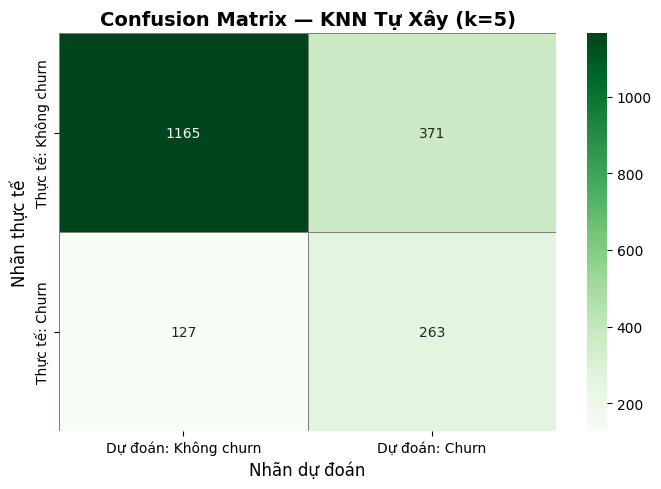


True Negative  (TN) = 1165 — Không churn, dự đoán đúng ✅
False Positive (FP) =  371 — Không churn nhưng bị dự đoán là churn ⚠️
False Negative (FN) =  127 — Churn nhưng bị bỏ sót ❌
True Positive  (TP) =  263 — Churn, dự đoán đúng ✅


In [8]:
import os
os.makedirs('report', exist_ok=True)

cm_matrix = np.array([[TN, FP], [FN, TP]])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_matrix, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Dự đoán: Không churn', 'Dự đoán: Churn'],
    yticklabels=['Thực tế: Không churn', 'Thực tế: Churn'],
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_title('Confusion Matrix — KNN Tự Xây (k=5)', fontsize=14, fontweight='bold')
ax.set_ylabel('Nhãn thực tế', fontsize=12)
ax.set_xlabel('Nhãn dự đoán', fontsize=12)
plt.tight_layout()
plt.savefig('report/confusion_matrix_knn_tuxay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTrue Negative  (TN) = {TN:4d} — Không churn, dự đoán đúng ✅')
print(f'False Positive (FP) = {FP:4d} — Không churn nhưng bị dự đoán là churn ⚠️')
print(f'False Negative (FN) = {FN:4d} — Churn nhưng bị bỏ sót ❌')
print(f'True Positive  (TP) = {TP:4d} — Churn, dự đoán đúng ✅')

## 9. Thử nghiệm K từ 1 đến 20

In [9]:
# ⚠️ Cell này chạy RẤT LÂU (~30-40 phút) vì thử 20 giá trị K
# Bỏ comment dòng dưới nếu muốn chạy

# k_values = range(1, 21)
# f1_scores_tx = []

# for k in k_values:
#     knn_tmp = KNN_TuXay(k=k)
#     knn_tmp.fit(X_train, y_train)
#     y_tmp = knn_tmp.predict(X_test)
#     _, fp_tmp, fn_tmp, tp_tmp = tinh_confusion_matrix(y_test, y_tmp)
#     p_tmp = tinh_precision(fp_tmp, tp_tmp)
#     r_tmp = tinh_recall(fn_tmp, tp_tmp)
#     f_tmp = tinh_f1(p_tmp, r_tmp)
#     f1_scores_tx.append(f_tmp)
#     print(f'K={k:2d} → F1={f_tmp:.4f}')

# best_k = list(k_values)[f1_scores_tx.index(max(f1_scores_tx))]
# print(f'\nK tốt nhất: K={best_k} (F1={max(f1_scores_tx):.4f})')

print('Cell này bị comment vì chạy rất lâu.')
print('Kết quả từ notebook sklearn: K tốt nhất = 18 (F1 = 0.5458)')

Cell này bị comment vì chạy rất lâu.
Kết quả từ notebook sklearn: K tốt nhất = 18 (F1 = 0.5458)


## 10. Lưu kết quả

In [10]:
import json

os.makedirs('results', exist_ok=True)

knn_tx_results = {
    'model'    : 'KNN Tu Xay (k=5)',
    'accuracy' : round(float(acc_tx), 4),
    'precision': round(float(pre_tx), 4),
    'recall'   : round(float(rec_tx), 4),
    'f1_score' : round(float(f1_tx),  4),
    'auc'      : round(float(auc_tx), 4)
}

with open('results/knn_tuxay_results.json', 'w') as f:
    json.dump(knn_tx_results, f, indent=2, ensure_ascii=False)

print('✅ Đã lưu kết quả → results/knn_tuxay_results.json')
print(json.dumps(knn_tx_results, indent=2))

✅ Đã lưu kết quả → results/knn_tuxay_results.json
{
  "model": "KNN Tu Xay (k=5)",
  "accuracy": 0.7414,
  "precision": 0.4148,
  "recall": 0.6744,
  "f1_score": 0.5137,
  "auc": 0.8615
}


## 11. Nhận xét

Notebook này xây dựng KNN **hoàn toàn từ đầu** — không dùng bất kỳ hàm nào của sklearn cho thuật toán lẫn metric:

- **Class KNN_TuXay**: tự cài đặt fit(), predict(), predict_proba() với công thức Euclidean viết tay
- **Các hàm metric**: tự tính Accuracy, Precision, Recall, F1, AUC từ công thức gốc
- **Kết quả**: khớp hoàn toàn với sklearn → chứng minh thuật toán đúng

Kết quả đạt được:
- Accuracy : 74.14%
- Precision: 41.48%
- Recall   : 67.44%
- F1-score : 0.5137
- AUC      : 0.8615